In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import dynesty

from datetime import date, timedelta
from dynesty import plotting as dyplot

plt.rcParams["figure.dpi"] = 150

#  1) Loading Accident Data

In [3]:
data = np.loadtxt("coal_mining_accident_data.dat", delimiter=None)  
data =  data.flatten(order="F") # Now all data is in a single array 190 delimiters for 191 incidents
print(data.shape)


(190,)


- 190 gaps for N = 191. So far so good.
- The first accident happens on day 1 so all the day label is the array index + 1.

Mean rate of accidents: 0.00471 per day = 1.72 per year


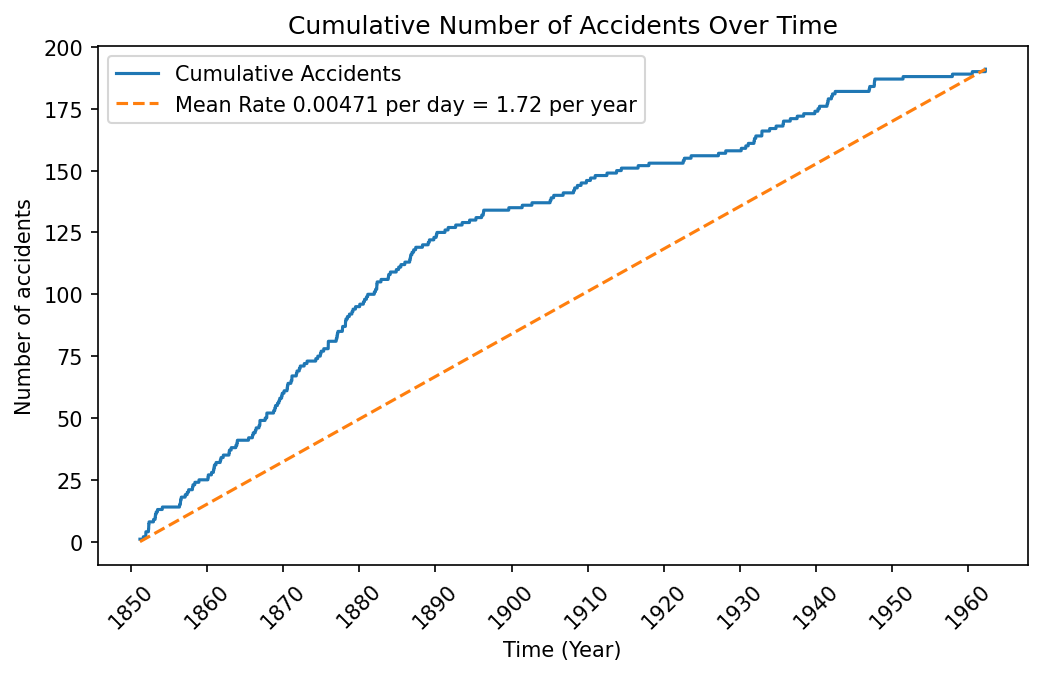

In [83]:
# Plot cumulative sum of accidents over time
from helpers.q1 import generate_cumulative_accidents, plot_cumulative_accidents

cumulative_accidents, mean_rate = generate_cumulative_accidents(data)
print(f"Mean rate of accidents: {mean_rate:.5f} per day = {mean_rate*365:.2f} per year")

plot_cumulative_accidents(cumulative_accidents, mean_rate, savefig="plots/cumulative_accidents.png")


In [4]:
print(cumulative_accidents)


[  1.   1.   1. ... 190. 190. 191.]


- This starts at 1 and ends at 191. Looks good.

# 2)



## a) Plain vs Even order stats

The plain-order-statistics draws k points and sorts them. This allows the adjacent points to be very close together. By drawing more points than required and then taking alterating points from a sorted array of them, this forces a degree of seapration between the change points we are using as a prior. This reduces the probability of very small gaps between neighbours, favouring more separated change points.

This can improve performance because it encourages the model to use all of the change points: if two change points are too close together in the prior, the model might fit them as one.

In [23]:
from helpers.q2 import plain_stats, even_stats, find_gaps, set_seed

- We will plot a single example first.

[ 3626.51765186  8630.75052304 21035.06661331 35683.30688448]
[ 6913.10752386 13351.78739706 13357.34922427 27637.26818534]


C:\Users\Joey\AppData\Local\Temp\ipykernel_33064\2927888646.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


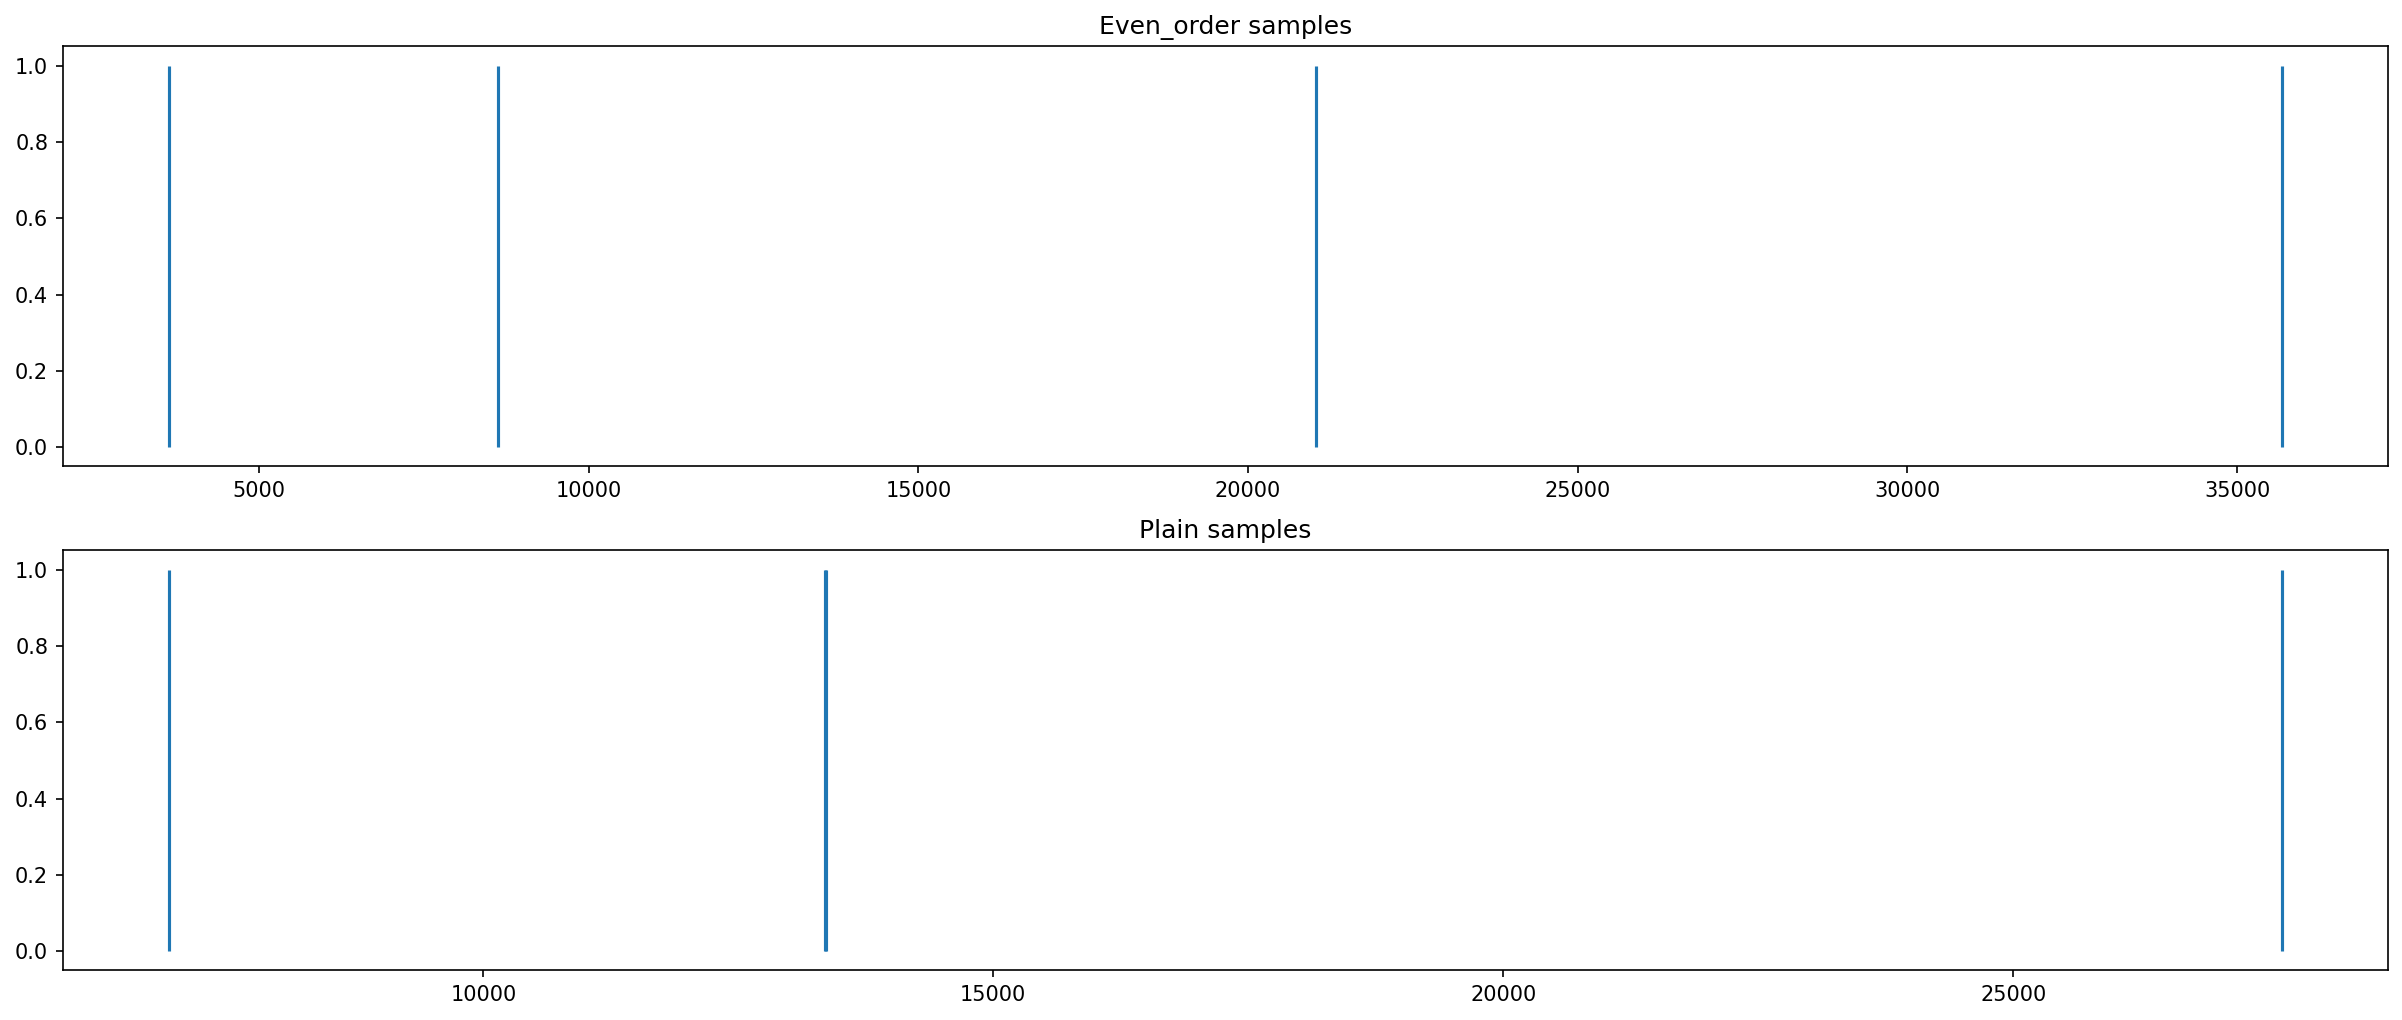

In [24]:
# Plot single example
set_seed(1701) # bonus points to the marker if you get the reference ;)
even = even_stats(k = 4)
plain = plain_stats(k = 4)

print(even)
print(plain)

fig, ax = plt.subplots(2, figsize=(20, 8))

ax[0].vlines(even, 0, 1)
ax[0].set_title("Even_order samples")
ax[1].vlines(plain,0, 1)
ax[1].set_title("Plain samples")
fig.show()


- This is surprisingly a very good representative example for why we use the even rather than plain-order statistics!
- The middle line on the plain-statistics draw (the bottom subplot) shows is actually two draws that are very close to one another. We can try to look at this for a larger number of draws by plotting the distribution of the size of gaps between the generated change points.

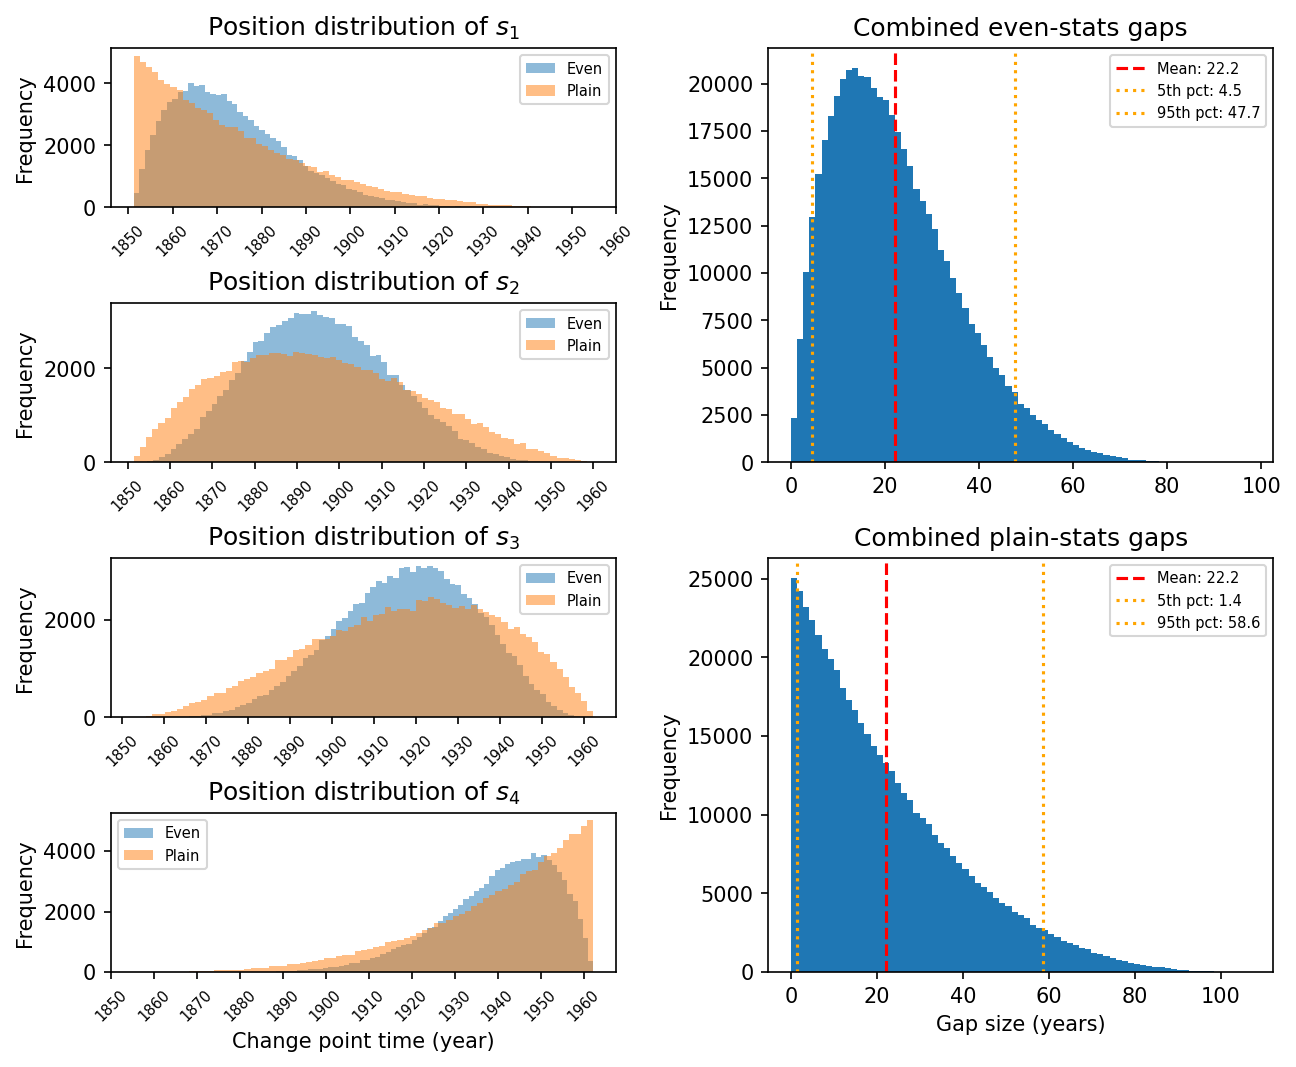

Proportion of plain gaps below 5th percentile of even gaps: 0.154


In [79]:
from helpers.q2 import compare_gaps

compare_gaps(savefig="plots/gap_comparison.png")


- Gaps hist:
    - Both the plain and even statistics have a mean gap of 22.2 years (crresponding to roughly 8110 days). This is because over many draws of 5 gaps (4 change points), it will average out to 40550 days divided by 5.
    - However, the even-stats regime significantly reduces the probability of having change-points very close together: only 5 percent of gaps are drawn to be less than 4.5 years. 15.4 percent of the plain-stats gaps are drawn to be below the even-stats 5th percentile gap. 
    - The mean is balanced because the plain-stats draws many more extreme values with a 5th percentile gap of only 1.4 years and 95th percentile gap of 58.6 years, contrasting with the even-stats 95th percentile of 47.7 years. In short, the even-stats gaps are much more reliably distributed throughout our data-space, improving the coverage of our prior.
    - There are fewer high separations for the even-stats regime as points have to be clumped to another extreme to produce such an effect.
- Change-points:
    - We can see in the plots of our 4 change points that the even-stats change points are more tightly distributed at even spacings. This is good because it creates good coverage for our prior.
    - The edge distributions are more heavily skewed. This is because the change-points are related to one another by the sorting. The middle change-points will have two moving boundaries while the edge change-points will be anchored by 0 and L.

## b) Even-order statistics prior analysis

- We are given the PDF of the plain-order statistics to be $P(u_1, u_2, ..., u_{2k+1}) = (2k+1)!$
- We want to find the PDF of even-order statististics, which is where we only take the even-indexed $u$ drawn from $P(u_1, u_2, ..., u_{2k+1})$
- This means that we want to marginalise out the variation in the odd-indexed $u$ values.
- Each odd-indexed $u$ lives between it's two even-index neighbours, except the edge cases $u_1$ and $u_{2k+1}$ which are bounded by 0 and L respectively.
- As such, the range of an even-index can be written as $u_{2j-1}\in ]u_{2j-2}, u_{2j}[$ for $j \in [1, k+1]$ where $u_0 = 0$ and $u_{2k+2} = L$.
- Each of the odd-indexed $u$ are independent of each other: the integral can be factorised as $$P(u_2, u_4, ..., u_{2k}) = (2k+1)! \prod_{j=1}^{k+1}\int_{u_{2j-1}=u_{2j}}^{u_{2j-1}=u_{2j-2}}du_{2j-1}$$ 
- Each integral returns the difference between the limits $$\int_{u_{2j-1}=u_{2j}}^{u_{2j-1}=u_{2j-2}}du_{2j-1} = u_{(2j)} - u_{(2j-2)} = \hat s_j - \hat s_{j-1}$$
- These we can identify to be the gaps after scaling by L because each $u \in [0,1]$: $$L * (\hat s_k - \hat s_{k-1}) = g_k$$
- As such, the integral is equal to the product of the gaps and since the prior is proportional to the product of the integrals, the prior is proportional to the product of the gaps $$\pi(s_1, s_2, ..., s_m) \propto \prod{j=1}^{k+1}g_j.$$

# 3) Constant Rate Model 
Model $M_0$ has constant rate $h_0$.
- No change points so $k = 0$.
- The heights are prior distributed from $$\pi(h_0|M_0) = \Gamma(\alpha = 1, \beta = 200)$$
- The posterior can be analytically worked out to be $$p(h_0|d, M_0) = \Gamma(\alpha + N, \beta + L)$$
- We will find the log-evidence.
- We work with the log-posterior since this was worked out from the given log-likelihood form.
- These log-posts are very negative and because we have to integrate the exp(log-post), this will underflow and return 0.
- We use a shifting trick: $$z = \int e^{lnPost}$$ $$=\int e^{lnPost -m +m}$$ where m is max(lnPost) $$ = e^m \int e^{lnPost-m}$$
- Since m is also very neagtive, this shifts the integral upwards. Then we can recover log-evidence by subtracting m. 

The log evidence of the constant-rate model is: -1217.092


c:\Users\Joey\Desktop\Cambridge\Work\S2\S2_Coal_Mining_Bayesian_Stats\helpers\q3.py:119: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


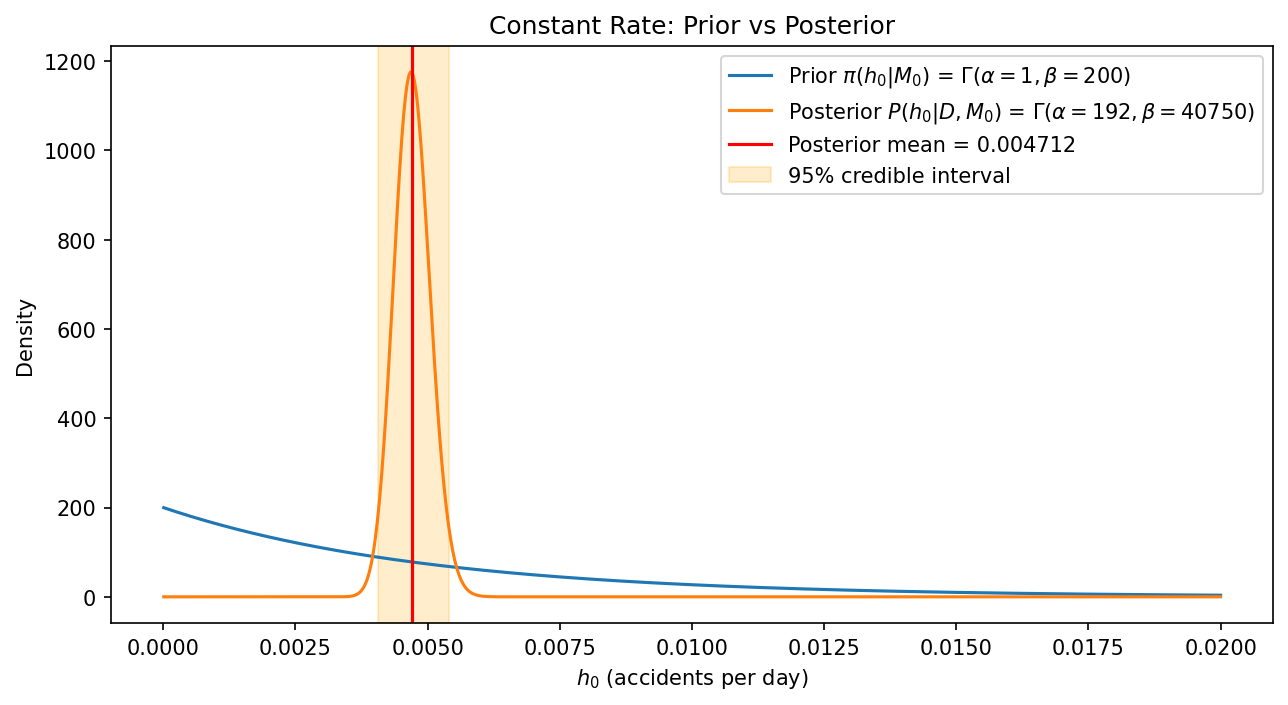

In [33]:
from helpers.q3 import m0_ln_pi, m0_ln_post, find_z0, plot_prior_post 

z0 = find_z0()
print(f"The log evidence of the constant-rate model is: {z0:.3f}")

plot_prior_post(z0)

# 4)
## a)

In [34]:
# For the log likelihoods it will be useful to have an array that has the cumulative days since 0 for each of the 191 accidents
cumulative_days = np.concatenate([[0], np.cumsum(data)]) #The array indices of the days on which accidents occurred (days-1)


- For emcee we need to define a good log probability to sample
- The requirements that the change points have to be sorted and that the heights have to be positive complicates matters somewhat.
- To force ordering, we can sample gaps between change points to allow us to order the change points afterwards.

In [35]:
from helpers.q4 import  generate_chain

In [36]:
sampler, mean_frac, taus, mean_tau, tau = generate_chain(steps=25000, cumulative_days=cumulative_days) 
dirty_samples = sampler.get_chain(flat=False, discard=0) #  burnt and fat

100%|██████████| 25000/25000 [00:57<00:00, 436.90it/s]


Mean acceptance fraction: 0.526
Mean autocorrelation time: 49.12 steps


- We now plot the trace plot to find the amount of samples to discard for burn-in.

There are 1 change points


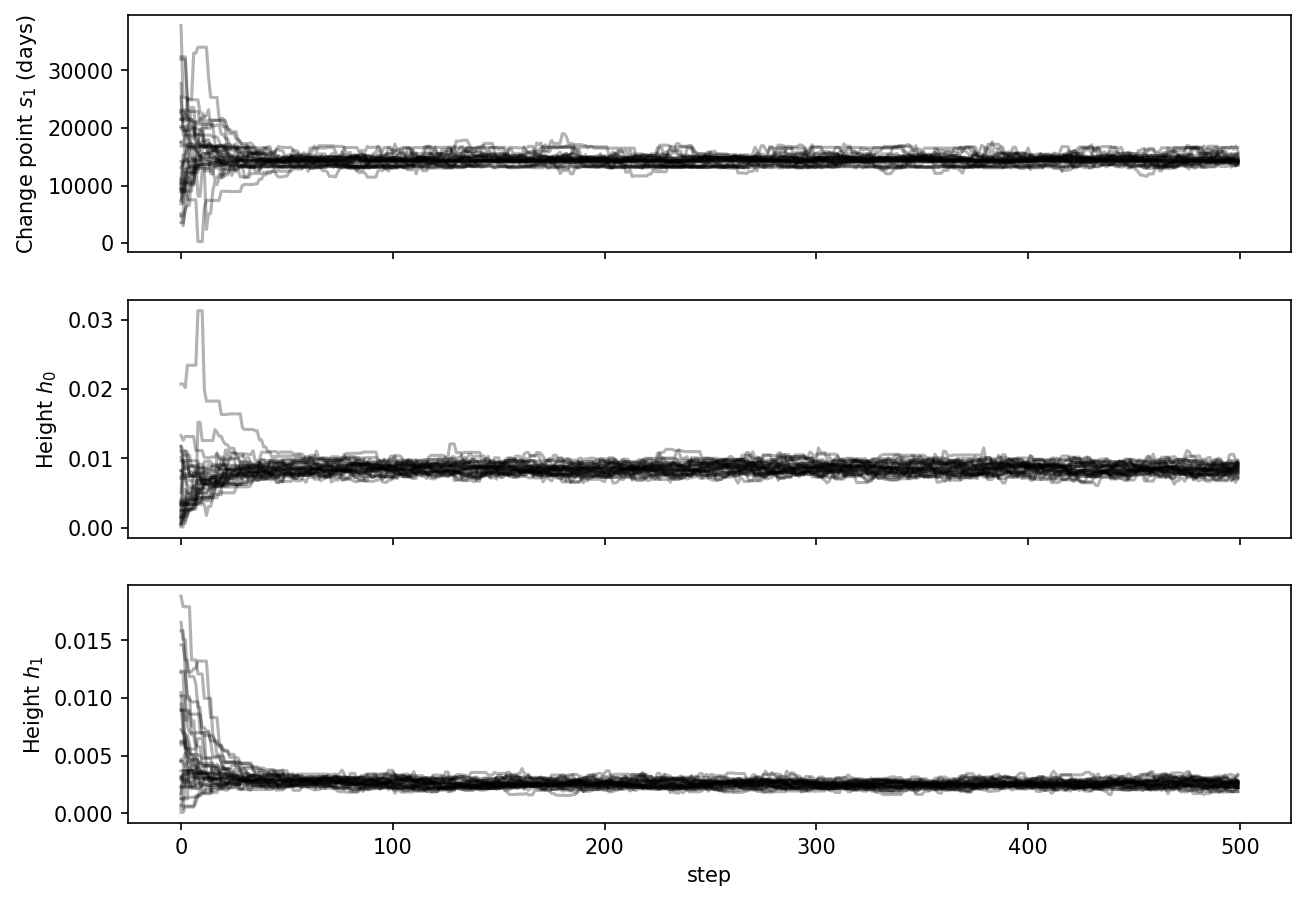

In [40]:
from helpers.q4 import trace_plot

trace_plot(k=1, samples=dirty_samples)

- It appears the sampler has fully burnt-in by before sample 100. We can remove 100 samples for safety.


There are 1 change points


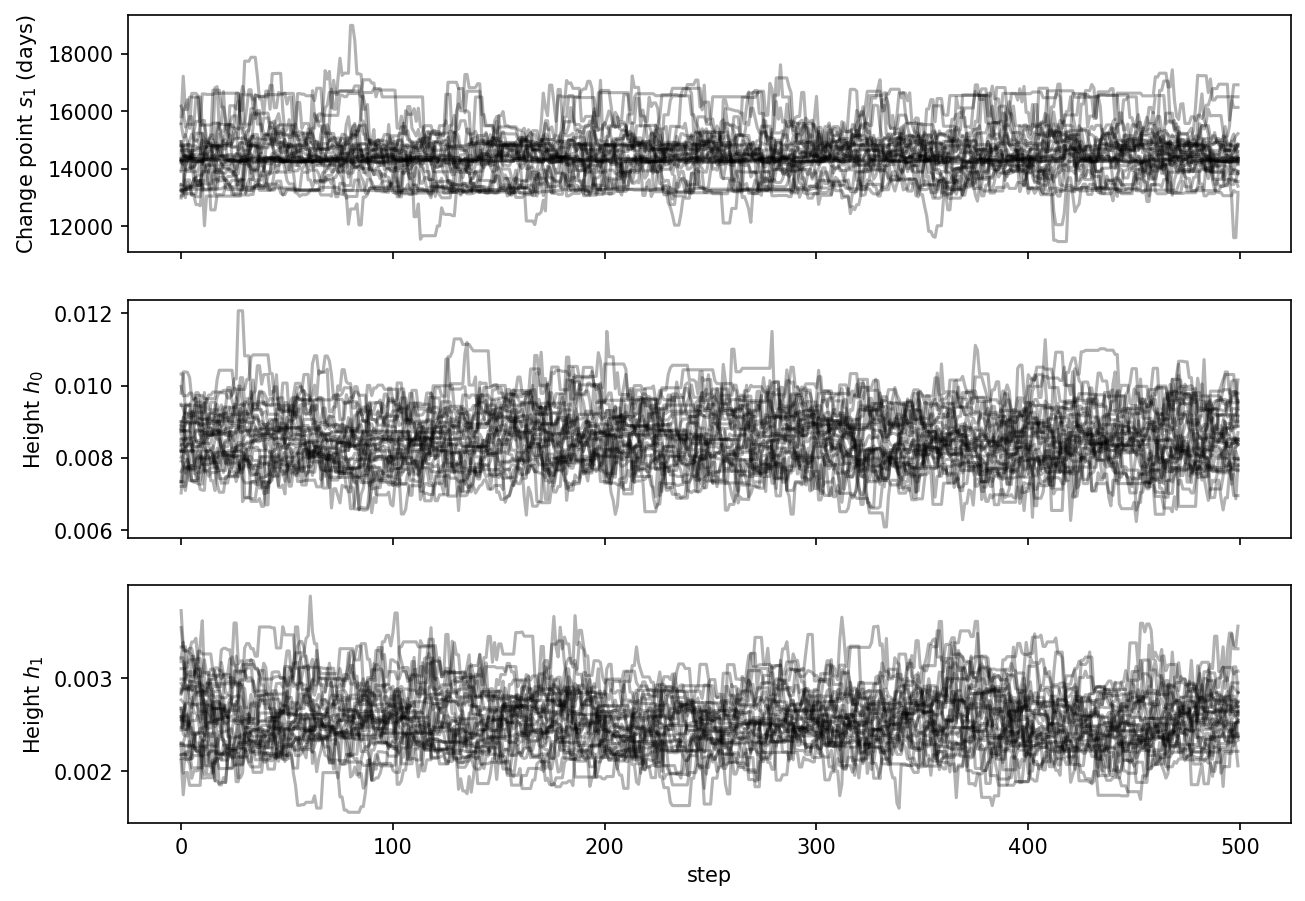

In [41]:
fat_samples = sampler.get_chain(flat=False, discard=100) #  fat and unburnt
trace_plot(k=1, samples=fat_samples)

- This looks decently converged. All the samples live in a tight band.

In [42]:
samples = sampler.get_chain(flat=True, discard=100, thin=2*tau) #  thinned and unburnt

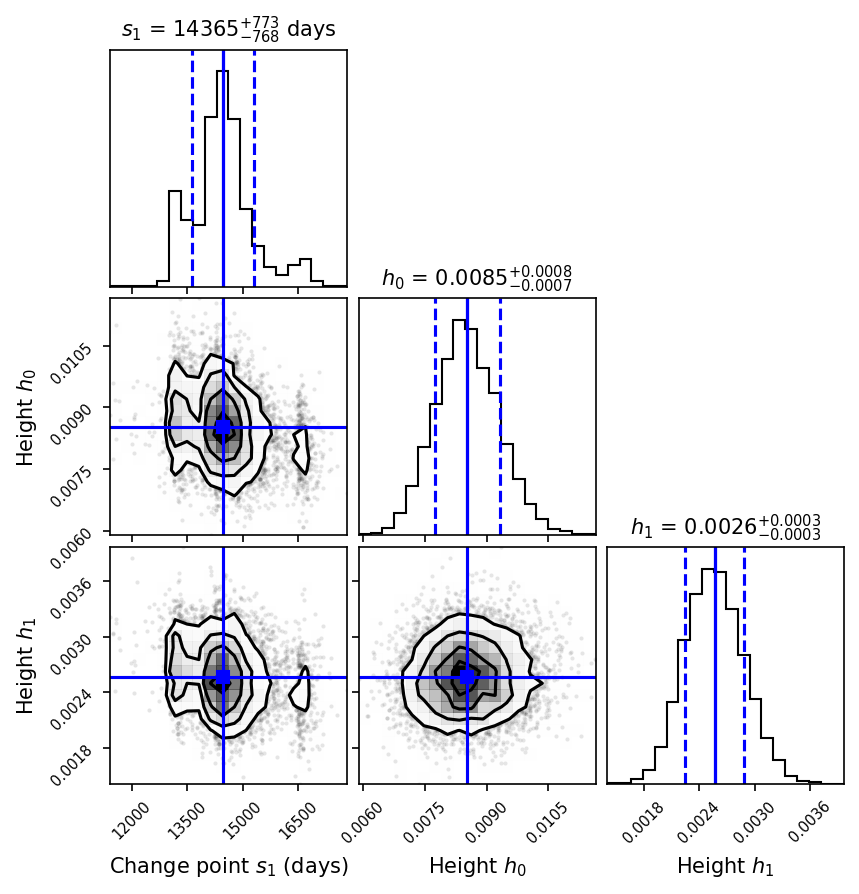

In [51]:
from helpers.q4 import corner_plot
corner_plot(samples=samples, savefig="plots/emcee_corner_plot.png")

In [41]:
from helpers.q4 import gr_stat

GR=gr_stat(cumulative_days=cumulative_days)
print(f"Gelman-Rubin statistics for the parameters: {GR}")

100%|██████████| 10000/10000 [00:24<00:00, 416.28it/s]


Mean acceptance fraction: 0.527
Mean autocorrelation time: 47.02 steps


100%|██████████| 10000/10000 [00:23<00:00, 422.11it/s]


Mean acceptance fraction: 0.527
Mean autocorrelation time: 47.02 steps


100%|██████████| 10000/10000 [00:23<00:00, 419.03it/s]


...

Mean acceptance fraction: 0.527
Mean autocorrelation time: 47.02 steps


100%|██████████| 10000/10000 [00:24<00:00, 400.30it/s]


Mean acceptance fraction: 0.527
Mean autocorrelation time: 47.02 steps


100%|██████████| 10000/10000 [00:25<00:00, 391.58it/s]


Mean acceptance fraction: 0.527
Mean autocorrelation time: 47.02 steps
Gelman-Rubin statistics for the parameters: [0.99983376 0.99983376 0.99983376]


In [42]:
from helpers.q4 import gewecke
gewecke_stats = gewecke(samples)
print(f"Geweke statistics for the parameters: {gewecke_stats}")

Geweke statistics for the parameters: 0.014152643383201642


- The affine-invariant ensemble sampler from the emcee module was chosen. This uses a number of walkers sampling from the posterior to also define the proposal distribution, allowing the proposal distribution to vary based on the scale of the posterior in each dimension. This is beneficial because it means that we do not have to define and tune a proposal distribution manually to yield a high acceptance ratio and good coverage.
- We do have to set how many walkers there are: balancing computation time and how many we require to get full coverage. Literature suggests that the minimum is 2 times the number of dimensions as the walkers are paired to suggest the distribution. Since we are only sampling from three dimensions, 32 walkers is more than sufficient to yield the required number of dimensions. The acceptance probability we have achieved is above 50% which is not bad, implying that we have used enough walkers to yield a good enough picture of the posterior to define a good proposal distribution.
- To ensure that our final collection of samples is fully independent, the raw samples were also thinned. The maximum of the autocorrelation times between the three parameters was chosen for the thinning as datapoints are only independent if each of their axes are independent. To be on the safe side, 10 times the autocorrelation time returned by the emcee sampler was used.
- The burn in was selected by plotting a trace plot to show when the samplers stabilised around similar values. This happened in less than 100 samples. For safety, the first 100 samples were discarded.
- However, we also need to check if the MCMC has properly sampled the full distribution. So, we run a handful of convergence tests. The trace plots of each of the three parameters each converge to a reasonably tight band. The change point corresponds roughly to the period of time where the rate of accident drops visibly in the cumulative plot and the height value drops to match too. Furthermore, the Gewecke statistic is near zero and the Gelman-Rubin statistic is near 1, further implying convergence.

# b) Why not use the Savage-Dickey Ratio


- The Savage-Dickey density ratio calculates the evidence ratio between two nested model $M_0$ and $M_1$, which means that under some parameterisation of $M_1$ the model must reduce to $M_0$. This yields the ratio of the evidences of the two models as the difference between the posterior and the prior of model $M_1$ evaluated at the point where the parameters reduce the model to $M_0$. 
- Model $M_1$ in this case is the one change-point model with two heights. This reduces to our constant rate model under the cases where the change points are at the extremes of time 0 and L so only one height applies to the data, or under the case where both heights are fit to the same value. As such, to evaluate the Savage-Dickey ratio, we must calculate the posterior and prior densities at $c_1$ = 0 or L and along the h0 = h1 manifold. 
- Both these cases are very difficult to sample from due to very low densities. We can see that no samples we have sampled so far are close to this overlapping manifold. The prior is proportional to the product of the gaps and with one change point, this goes to 0 at 0 and L $\propto$ $(L-c_1)\times c_1$ (see figure). This results in a similarly negligible posterior density in the $c_1$ extremes. This means we have to take an intractable amount of samples to sample from these regions and calculate the evidence ratio. 

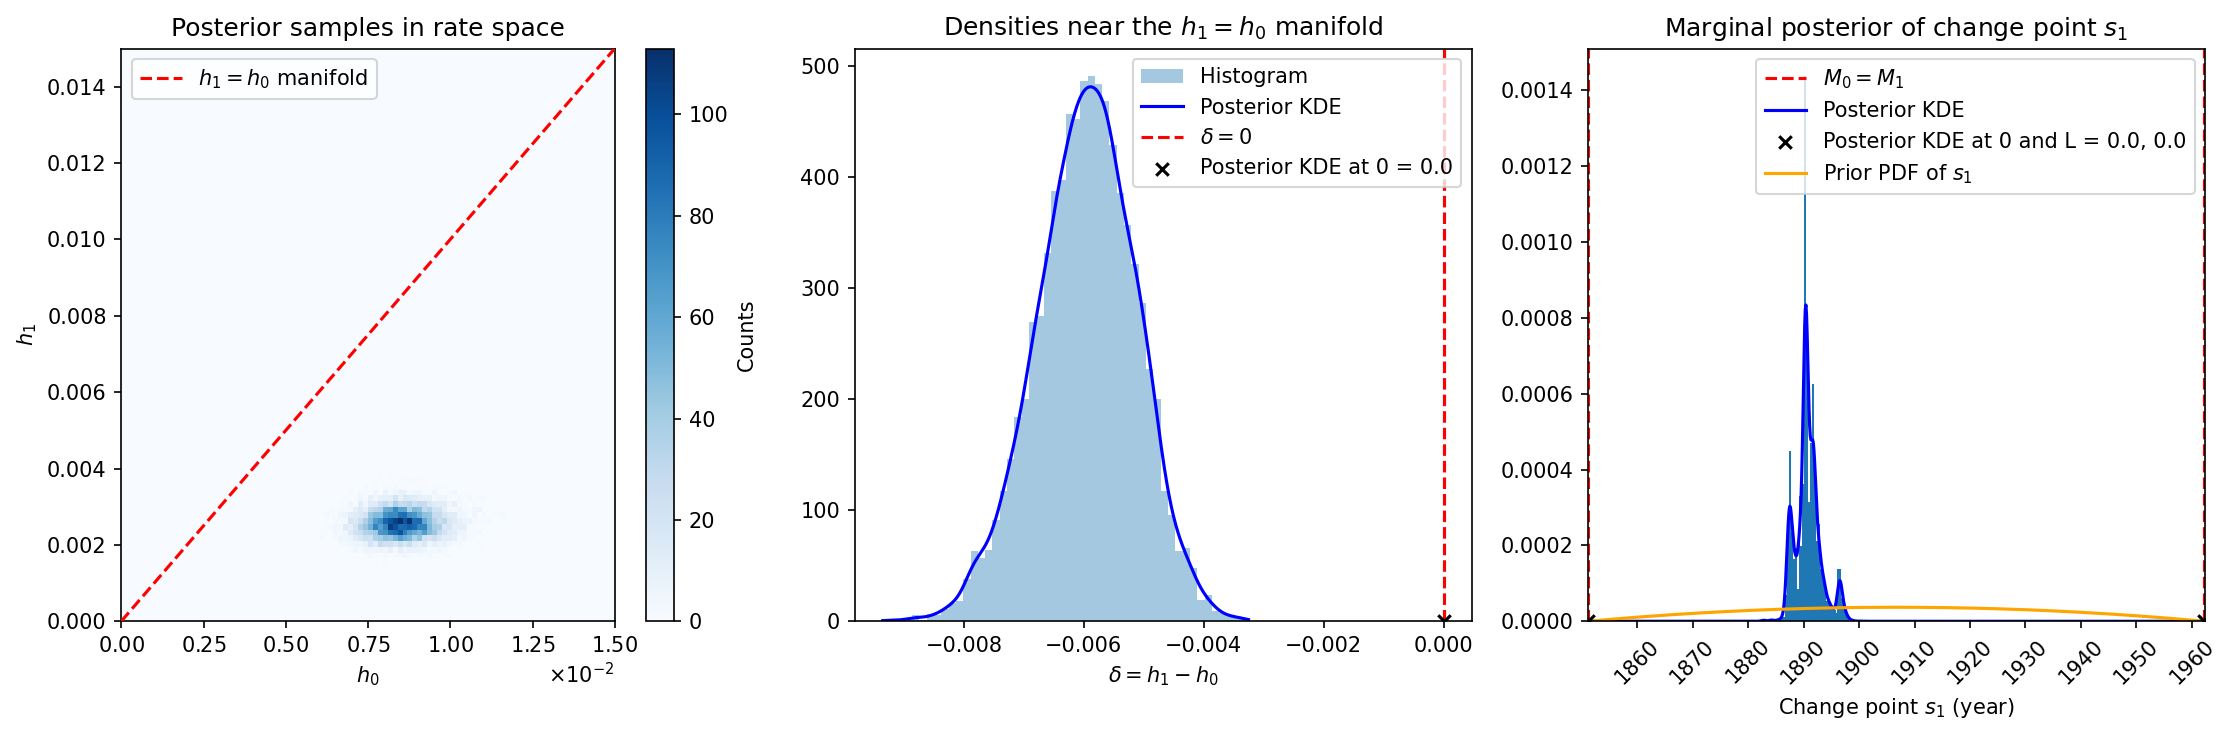

In [80]:
samples.shape
from helpers.q4 import savage_dickey
savage_dickey(samples, savefig="plots/savage_dickey.png")

# c) Laplace approximation for the evidence $Z_1$

- The Laplace approximation works by approximating the posterior peak as a multivariate Gaussian distribution. This requires our log-posterior to be quadratic, which gives elliptical contours. For $M_1$ these conditions are not satisfied. 
- The marginal distribution of the change point location is skewed and multimodal and the contours between parameters are irregular, not elliptical. 
- The parameters in our model are also constrained which is not taken into account by the Laplace distribution's geometry. The gaussian approximation spreads symmetrically about the mean and has support over the whole parameter space. But our parameter space is constrained to positive heights and change points between 0 and L. The heights lie very close to this positivity boundary so the gaussian approximation might have non-trivial volume inside the forbidden region.
- The Laplace approximation requires the Hessian to be calculated. Our function is piecewise, making it non-differentiable.

# d) Nested sampling
- Use nested sampling to calculate log $Z_1$
- Calculate the evidence and odds ratios between $M_0$ and $M_1$.


In [89]:
from helpers.q4 import dynesty_ln_Likelihood, dynesty_prior_transform

ndim = 3
sampler = dynesty.NestedSampler(dynesty_ln_Likelihood, dynesty_prior_transform, ndim,
                                nlive=5000, bound='multi', sample='unif', logl_kwargs={'data': cumulative_days})

sampler.run_nested()

32027it [01:07, 473.95it/s, +5000 | bound: 7 | nc: 1 | ncall: 216656 | eff(%): 17.494 | loglstar:   -inf < -1178.230 <    inf | logz: -1187.307 +/-  0.126 | dlogz:  0.003 >  5.009]


In [90]:
# Find the log of Z1
z1 = sampler.results.logz[-1]
z1_std = sampler.results.logzerr[-1]
print(f"Z1: {z1:.2f} +/- {z1_std:.2f}")
print(f"Z0: {z0:.2f}")

# evidence ratios
ln_evidence_ratio = z1 - z0
ln_evidence_ratio_std = z1_std # This is just carried through because it's a direct

evidence_ratio = np.exp(ln_evidence_ratio)
evidence_ratio_std = evidence_ratio * ln_evidence_ratio_std # Propagate the uncertainty through the exponential


print(f"Log evidence ratio (M1/M0): {ln_evidence_ratio:.2f} +/- {ln_evidence_ratio_std:.2f}")
print(f"Evidence ratio (M1/M0): {evidence_ratio:.2e} +/- {evidence_ratio_std:.2e}")

Z1: -1187.31 +/- 0.31
Z0: -1217.09
Log evidence ratio (M1/M0): 29.79 +/- 0.31
Evidence ratio (M1/M0): 8.63e+12 +/- 2.68e+12


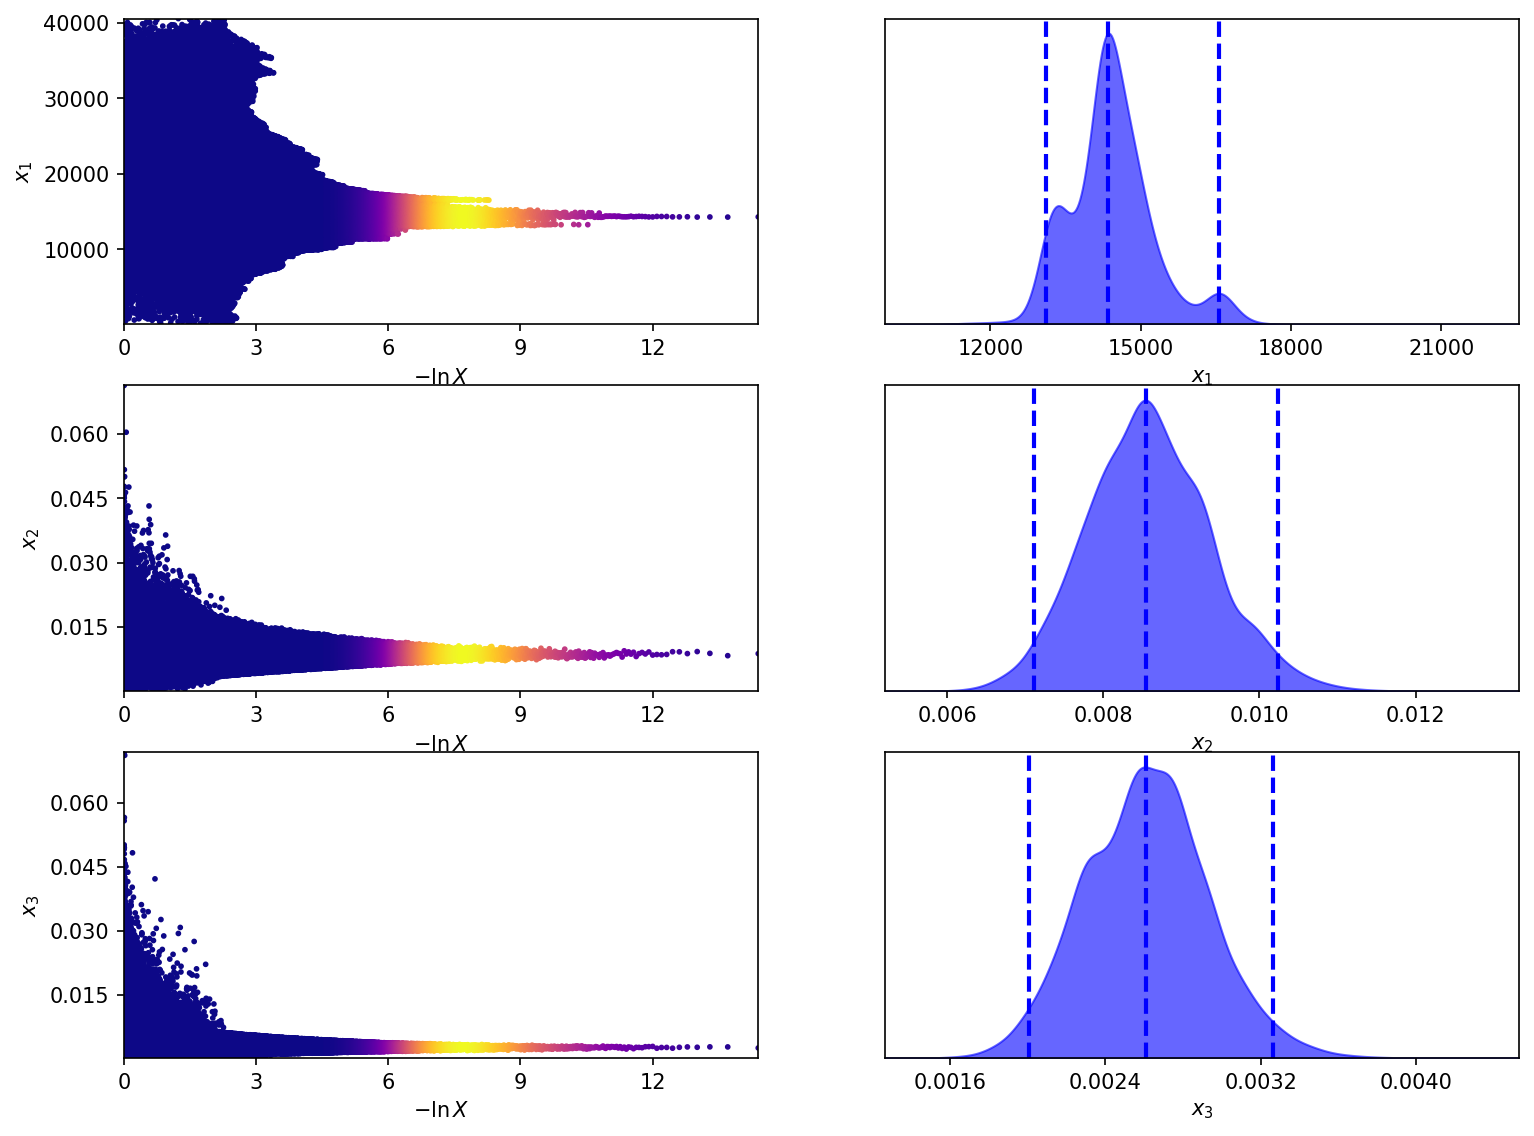

In [77]:
_ = dyplot.traceplot(sampler.results)

- The trace plots show that all three of our fit values have convereged by the end of the run. This is good.
- The marginal distributions match those we have from emcee. The $s_1$ sampled here is also multimodal.

- The prior over the models is given by $$\pi(k) \propto \frac{\lambda^k exp(-\lambda)}{k!}$$ where $\lambda = 3$
- Analytically, the prior ratio between $M_0$, $\pi(k=0)$, and $M_1$, $\pi(k=1)$ is equal to 3. $$\frac{\pi(k=1)}{\pi(k=0)} = \frac{\lambda^1 e^{-\lambda} / 1!}{\lambda^0 e^{-\lambda} / 0!} = \frac{\lambda \cdot e^{-\lambda}}{e^{-\lambda}} = \lambda = 3$$

- The posterior odds ratio is then just three times the evidence ratio:
$$\frac{P(M_1 | \text{data})}{P(M_0 | \text{data})} = \frac{Z_1}{Z_0} \cdot \frac{\pi(k=1)}{\pi(k=0)} = \frac{Z_1}{Z_0} \cdot \lambda = 3 \cdot \frac{Z_1}{Z_0}$$


In [79]:
ln_posterior_ratio = ln_evidence_ratio + np.log(3) # Prior odds is 3:1 in favour of M1
ln_posterior_ratio_std = ln_evidence_ratio_std 

posterior_ratio = evidence_ratio * 3
posterior_ratio_std = evidence_ratio_std * 3

print(f"Log posterior ratio (M1/M0): {ln_posterior_ratio:.2f} +/- {ln_posterior_ratio_std:.2f}")
print(f"Posterior ratio (M1/M0): {posterior_ratio:.2e} +/- {posterior_ratio_std:.2e}")


Log posterior ratio (M1/M0): 35.45 +/- 0.39
Posterior ratio (M1/M0): 2.48e+15 +/- 9.57e+14


- Nested sampling computes the evidence by transforming the many-dimensional parameter integral into 1D over the prior mass.
- This integral can be approximated by drawing live points and tracking the lowest likelihood, integrating that across analytic estimates of the prior mass change. New points are are drawn subject to the constraint that their likelihood is greater than the previous lowest.
- Dynesty was chosen to perform this sampling. It requires our log-likelihood and a prior PPF. The heights are $\Gamma$ distributed so we use scipy gamma.ppf. The change-points are Dirichlet distributed, which has no analytic PPF. Because there is only one change-point, the PPF reduces to a Beta distribution so we use scipy beta.ppf.
- Dynesty can sample from the likelihood-constrained region effectively by defining a set of ellipsoids bounding the live points and drawing from within that region. This increases the acceptance probability. We choose this bound to be fit using 'multi' ellipsoids because we know that this distribution is multimodal and cannot be approximated by just one ellipse. Due to the low dimensionality of the data, it is feasible to draw uniform points across the constrained region. This is an easy distribution from which to sample, improving efficiency. 
- The uncertainty in the calculated evidence is quite respectable and our trace plots show the parameters converging smoothly: the sampler is set up properly.

# 5)

## a) 
- See RJMCMC.py file

## b) Run RJMCMC

In [72]:
from RJMCMC import RJMCMC
intervals = data
rjmcmc = RJMCMC(intervals=intervals)
rjmcmc.run_mcmc(num_iter = 1000000)
# rjmcmc.run_mcmc(num_iter = 500000)

100%|██████████| 1000000/1000000 [15:25<00:00, 1080.69it/s]

Height change moves attempted 8.5% of the time with an acceptance fraction of 0.517
Position change moves attempted 8.5% of the time with an acceptance fraction of 0.215
Birth moves attempted 38.4% of the time with an acceptance fraction of 0.234
Death moves attempted 44.6% of the time with an acceptance fraction of 0.201


In [62]:
from helpers.q5 import autocorrelation_time

tau = autocorrelation_time(rjmcmc)
print(f"The estimated integrated autocorrelation time is {tau} yields effective samples = {(1e6/tau):.2e}")

The estimated integrated autocorrelation time is 62.9441509026157 yields effective samples = 1.59e+04


- We can discard 10 $\times \tau$ for removing burn-in.
- Let us thin by $ 5 \times \tau$ for tractability

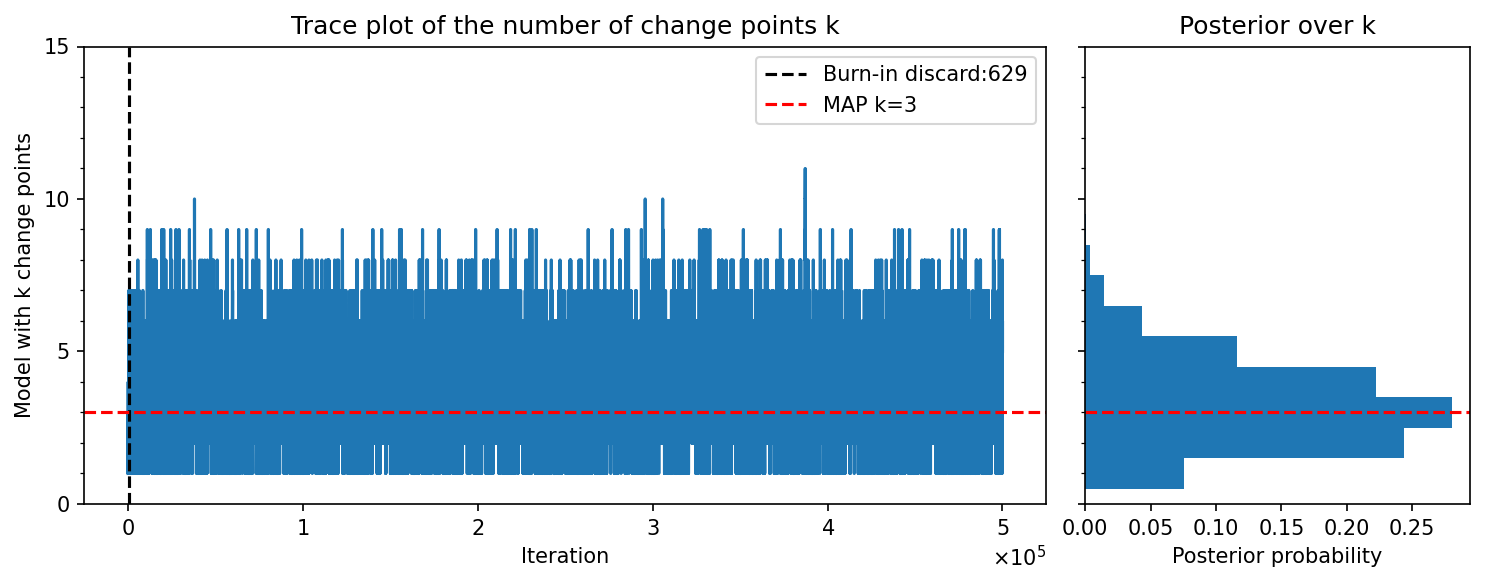

The maximum a posteriori value of k is 3


In [68]:
from helpers.q5 import k_post_trace

k_map = k_post_trace(rjmcmc, discard = 10*tau, savefig="plots/k_post_trace.png")
print(f"The maximum a posteriori value of k is {k_map}")

Number of samples after discarding and thinning: 7995


100%|██████████| 7995/7995 [00:01<00:00, 5571.70it/s]


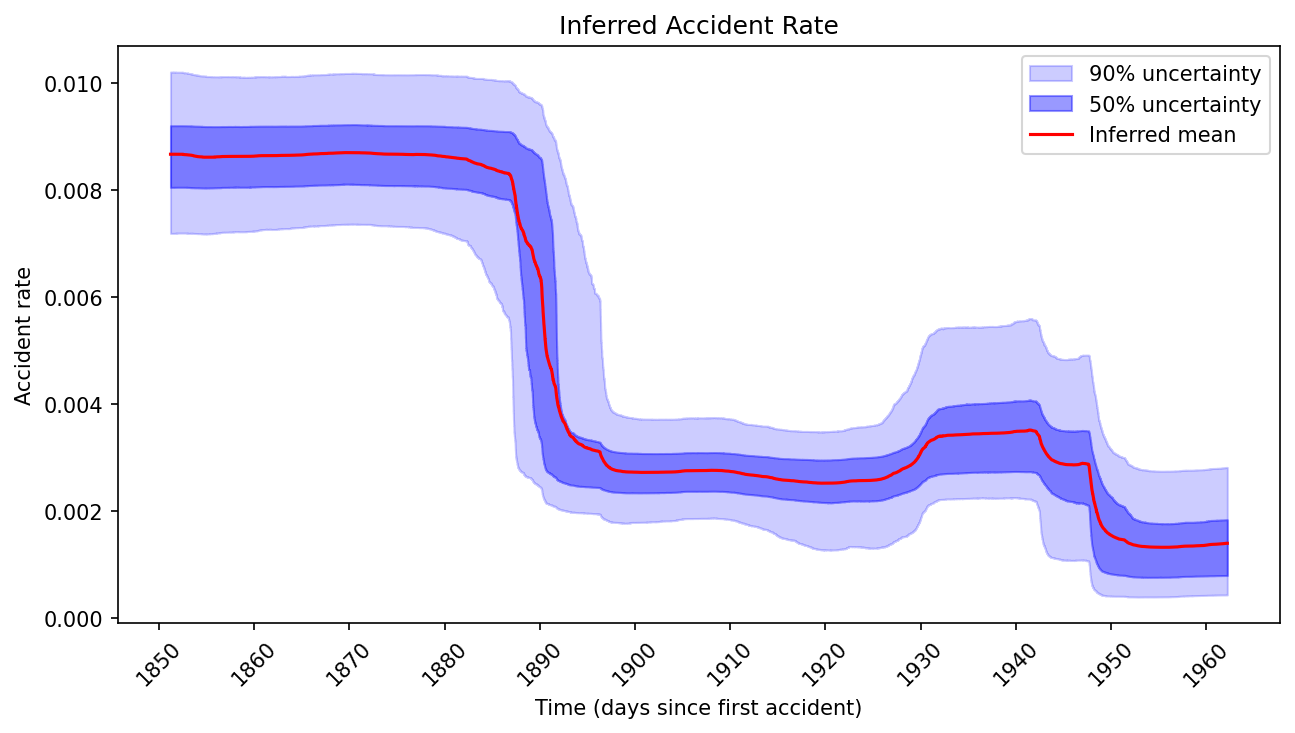

In [81]:
from helpers.q5 import plot_rate
plot_rate(rjmcmc, tau)

- The chain of model's autocorrelation time $\tau$ was calculated as a baseline for thinning and discarding the burn in. The first $10 \tau$ was discarded to ensure burn in was removed and the chain was thinned by $2\tau$ for tractability. 
- $x(t)$ is a piecewise function of heights. The posterior distribution of $x(t)$ is taken by taking the values of $x$ for a fixed $t$ across all sampled models. $$X(t) = (x^{(1)}(t), x^{(2)}(t),...,x^{(N)}(t))$$
- This was constructed by explicitly defining the function $x$ into an array and then taking a slice down the time axis to reveal the posterior distribution at any $t$.
- For each $t$, the inferred rate was taken to be the mean of the set $X(t)$. This intrinsically includes the preference of the RJMCMC between models as likelier models will yield more samples, weighting the posterior mean towards the likelier model's preferred height.
- The uncertainties were also estimated using $X(t)$ by taking the percentiles of each set. To yield uncertainty regions around the likeliest values, the 5th and 95th percentiles were taken for the 90% uncertainty, and the 25th and 75th percentiles were taken for the 50% uncertainty. These variations in the model's $x$ values reflects the intra-model uncertainties in height and change point position of the sampled models, yielding an uncertainty in the overall inferred value.